In [82]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from PIL import Image
import cv2
import os
from typing import Dict, List, Tuple, Optional
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
from types import SimpleNamespace

from segment_anything import sam_model_registry

In [83]:
data_dic = {
    "CVC_ClinicDB" : 0, # Colonoscopy   - 612 img / 612 mask
    "Darwin": 1,        # X-ray         - 6106 img / 6106 mask
    "DRIVE": 2,         # Fundus        - 40 img / 40 mask
    "DSB_2018": 3,      # Microscopy    - 670 img / 670 mask
    "ISIC_2018": 4,     # Dermoscopy    - 3694 img / 3694 mask
    "Montgomery": 1,    # X-ray         - 138 img / 138 mask
    "PCXA": 1,          # X-ray         - 55 img / 55 mask
    "Shenzhen" : 1,     # X-ray         - 566 img / 566 mask
    "UDIAT" : 5         # Ultrasound    - 163 img / 163 mask
}

idx_name = {
    0: "Colonoscopy",
    1: "X-ray",
    2: "Fundus",
    3: "Microscopy",
    4: "Dermoscopy",
    5: "Ultrasound"
}

In [84]:
def file_generator(folder_path = "../datasets"):
    """
    file path generator
    """
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            yield os.path.join(root, file)

In [85]:
lst = [x for x in file_generator()]
all_images = [x for x in lst if x.split("/")[-2] == "image"]
sorted_image = sorted(all_images, key=lambda x: x.split("/")[-1].split(".")[0])

all_masks = [x for x in lst if x.split("/")[-2] == "mask"]
sorted_mask = sorted(all_masks, key=lambda x: x.split("/")[-1].split(".")[0])

image_mask = list(zip(sorted_image, sorted_mask))

In [86]:
labels = []
for path in sorted_image:
    labels.append(data_dic[path.split("/")[2]])

## 图片可视化

In [87]:
images_for_vis = []
labels_for_vis = []

for idx in range(len(labels)):
    lab = idx_name[labels[idx]]
    if lab not in labels_for_vis:
        labels_for_vis.append(lab)
        images_for_vis.append(sorted_image[idx])
    if len(labels_for_vis) == 6:
        break

In [88]:
images_for_vis

['../datasets/DSB_2018/image/0.png',
 '../datasets/UDIAT/image/000001.png',
 '../datasets/Darwin/image/00000265_nCoV-Snohomish-20382862_web1_M1-Lungs-EDH-200201-640x300@2x.png',
 '../datasets/DRIVE/image/01.png',
 '../datasets/CVC_ClinicDB/image/1.png',
 '../datasets/ISIC_2018/image/ISIC_0000000.jpg']

In [89]:
labels_for_vis

['Microscopy', 'Ultrasound', 'X-ray', 'Fundus', 'Colonoscopy', 'Dermoscopy']

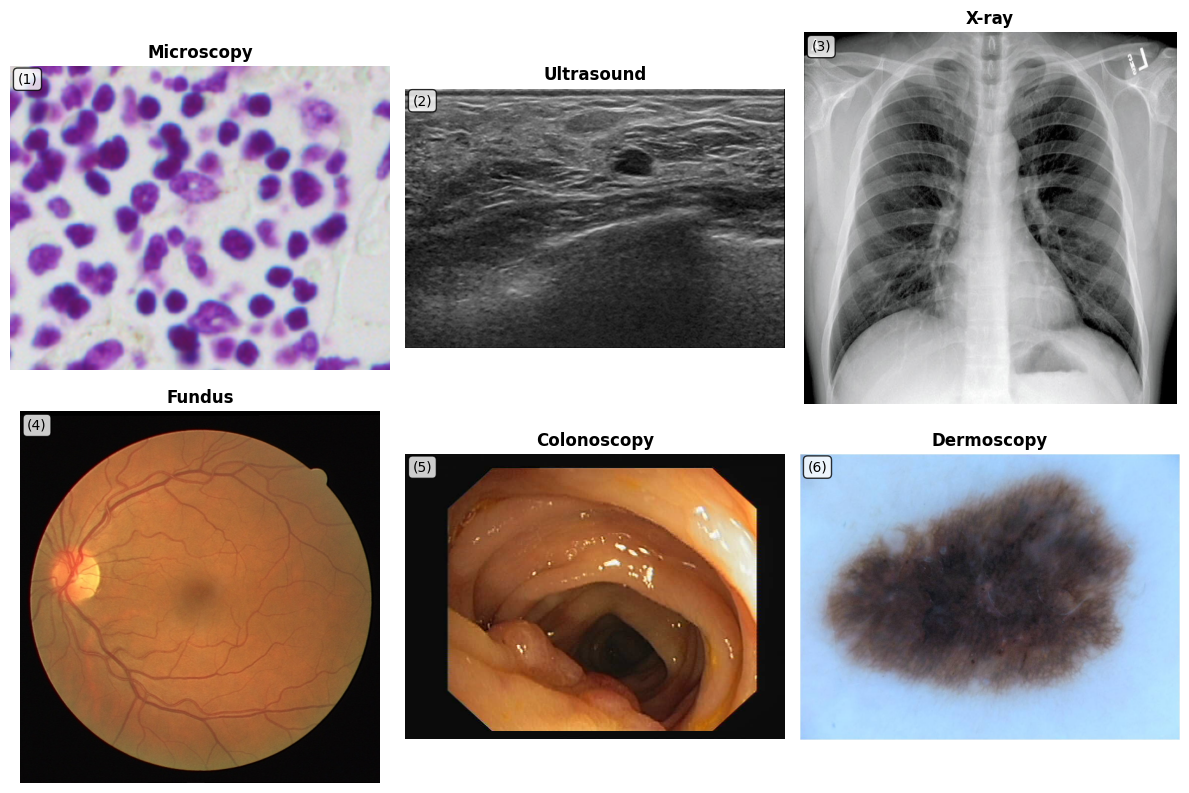

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# 示例：生成6张测试图片
images = []
titles = []

for i in range(6):
    # 创建随机图片
    image = Image.open(images_for_vis[i]).convert('RGB')
    image = np.array(image)
    images.append(image)
    titles.append(labels_for_vis[i])

# 绘制3×2网格
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2行3列

# 展平axes数组以便遍历
axes = axes.flatten()

for idx, (ax, img, title) in enumerate(zip(axes, images, titles)):
    # 显示图片
    ax.imshow(img)
    
    # 设置标题
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # 去除坐标轴
    ax.axis('off')
    
    # 可选：添加子图编号
    ax.text(0.02, 0.98, f'({idx+1})', 
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# plt.title("Sample for Six Medical Modalities")
plt.show()

/tmp/ipykernel_829770/3311996531.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image = np.array(image_tensor).transpose(1,2,0)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7205882..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1519828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid 

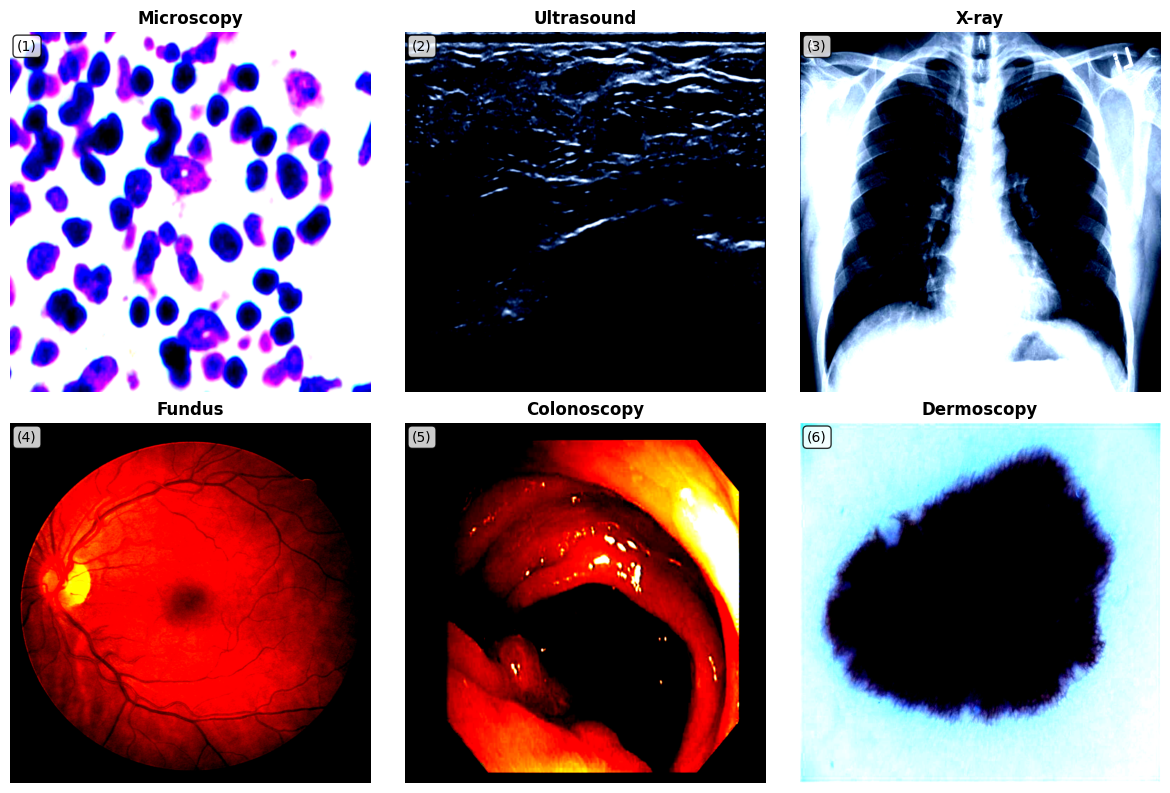

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# 示例：生成6张测试图片
images = []
titles = []

for i in range(6):
    # 创建随机图片
    image = Image.open(images_for_vis[i]).convert('RGB')
    image = np.array(image)
    image = cv2.resize(image, (1024, 1024))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
    image_tensor = (image_tensor - mean) / std
    image = np.array(image_tensor).transpose(1,2,0)
    images.append(image)
    titles.append(labels_for_vis[i])

# 绘制3×2网格
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2行3列

# 展平axes数组以便遍历
axes = axes.flatten()

for idx, (ax, img, title) in enumerate(zip(axes, images, titles)):
    # 显示图片
    ax.imshow(img)
    
    # 设置标题
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # 去除坐标轴
    ax.axis('off')
    
    # 可选：添加子图编号
    ax.text(0.02, 0.98, f'({idx+1})', 
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# plt.title("Sample for Six Medical Modalities")
plt.show()

In [92]:
class SAMDistillationDataset(Dataset):
    """SAM知识蒸馏数据集"""
    def __init__(self, 
                 image_mask: list, 
                 image_size: int = 1024,
                 augment: bool = False,
                 mask: bool = False):
        """
        参数:
        - image_dir: 图片目录
        - mask_dir: 分割掩码目录（可选）
        - image_size: 输入图片大小
        - augment: 是否数据增强
        """
        self.image_mask = image_mask
        self.image_size = image_size
        self.augment = augment
        self.mask = mask
        
        # 获取所有图片
        self.image_files = []
        self.mask_files = []

        for image, mask in image_mask:
            self.image_files.append(image)
            self.mask_files.append(mask)
            
        print(f"数据集地址加载完成: {len(self.image_files)} 张图片")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # 加载图片
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)
        
        # 如果对decoder也进行蒸馏，则需要加载掩码
        mask = None
        if self.mask:
            mask_path = self.mask_files[idx]
            mask = Image.open(mask_path).convert('L')
            mask = np.array(mask)
        
        # 数据预处理
        image, mask = self.preprocess(image, mask)
        
        # 转换为tensor
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        image_tensor = self.normalize(image_tensor)
        
        if mask is not None:
            mask_tensor = torch.from_numpy(mask).unsqueeze(0).float() / 255.0
        else:
            mask_tensor = torch.zeros(1, self.image_size, self.image_size)
        
        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'image_path': img_path
        }
    
    def preprocess(self, image: np.ndarray, mask: np.ndarray = None):
        """预处理图片和掩码"""
        # 调整大小
        image = cv2.resize(image, (self.image_size, self.image_size))
        
        if mask is not None:
            mask = cv2.resize(mask, (self.image_size, self.image_size), 
                             interpolation=cv2.INTER_NEAREST)
        
        # 数据增强 / 【暂时不做】
        if self.augment and np.random.random() > 0.5:
            # 随机水平翻转
            if np.random.random() > 0.5:
                image = cv2.flip(image, 1)
                if mask is not None:
                    mask = cv2.flip(mask, 1)
            
            # 随机亮度调整
            if np.random.random() > 0.5:
                brightness = np.random.uniform(0.8, 1.2)
                image = np.clip(image * brightness, 0, 255).astype(np.uint8)
            
            # 随机对比度调整
            if np.random.random() > 0.5:
                contrast = np.random.uniform(0.8, 1.2)
                image = np.clip(128 + contrast * (image - 128), 0, 255).astype(np.uint8)
        
        return image, mask
    
    def normalize(self, image: torch.Tensor) -> torch.Tensor:
        """SAM使用的归一化"""
        # SAM使用ImageNet归一化
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return (image - mean) / std

In [101]:
dataset = SAMDistillationDataset(image_mask=image_mask, image_size=1024, augment=False)
data_loader = DataLoader(dataset,batch_size=4,shuffle=True,num_workers=4)

数据集地址加载完成: 12044 张图片


Extracting Image From SAM Huge:   0%|                  | 0/3011 [00:00<?, ?it/s]

In [102]:
device_ids = list(range(torch.cuda.device_count()))
device = torch.device(f"cuda:{device_ids[0]}" if device_ids else "cpu")
print(f"可用 GPU: {device_ids}")
print(f"main GPU is device {device_ids[0]}")

# 加载模型
# model_type = "vit_l"
# checkpoint = '../pretrain/sam_vit_l_0b3195.pth'
model_type = "vit_h"
checkpoint = '../pretrain/sam_vit_h_4b8939.pth'
# model_type = "vit_b"
# checkpoint = '../pretrain/sam_vit_b_01ec64.pth'
image_encoder = sam_model_registry[model_type](checkpoint=checkpoint).image_encoder.to(device)
image_encoder = nn.DataParallel(image_encoder.to(device), device_ids=device_ids)

可用 GPU: [0, 1]
main GPU is device 0


In [104]:
image_encoder.eval()
prefix = "../SAM_h_features/image_feature"
pbar = tqdm(data_loader, desc="Extracting Image From SAM Huge")
for batch in pbar:
    with torch.no_grad():
        output = image_encoder(batch["image"].to(device))

    for idx in range(len(output)):
        path_split = batch["image_path"][idx].split("/")
        save_file = path_split[2] + "_set_file_" + path_split[-1].split(".")[0] + ".pt"
        torch.save(output[idx].cpu(), os.path.join(prefix, save_file))

In [99]:
import time
del image_encoder
time.sleep(10)

NameError: name 'image_encoder' is not defined

In [100]:
# 强制释放所有显存
import gc
import time
print(f"释放前 GPU 0 显存: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
gc.collect()
torch.cuda.empty_cache()
time.sleep(10)
print(f"释放后 GPU 0 显存: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

释放前 GPU 0 显存: 9.66 GB
释放后 GPU 0 显存: 0.02 GB
